In [1]:
#code in 3D
from random import seed
from random import random
import numpy as np
#import pandas as pd
#import seaborn as sns
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import numpy as np
from scipy.optimize import curve_fit
def fit_func(x, a, b):
    return a*x + b

import csv

def csv_to_array(file_path):
    data_array = []
    with open(file_path, 'r') as file:
        csv_reader = csv.reader(file)
        for row in csv_reader:
            data_array.append(row)
    data_array=np.array(data_array)
    return data_array

def csv_to_numpy_array(file_path):
    data_array = np.loadtxt(file_path, delimiter=',', dtype=str)
    return data_array

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import csv
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

In [2]:
ndini=[0.4,0.6,0.8,1,1.2,1.4,1.6,1.8,2,2.2,2.4,2.6,2.8,3]
gama=[0.4,0.6,0.8,1,1.2,1.4,1.6,1.8,2,2.2,2.4,2.6,2.8,3]

In [7]:
twosub=[]
i=0
while i<len(gama):
    j=0
    sublinears=[]
    while j<len(ndini):
        xname="slopforedgespeed,inutrientcon="+str(ndini[j])+\
        ",gamma="+str(gama[i])+".csv"
        xval = csv_to_numpy_array(xname)
        #print(xval)
        #float_array_x = np.array([float(x) for x in xval])
        h=float(xval)
        #print(h)
        if h>0:
            sublinears.append(0)
        elif h==0:
            sublinears.append(0.5)
        elif h<0:
            sublinears.append(1)
        j=j+1
    twosub.append(sublinears)
    i=i+1
#print(twosub)

In [8]:
np.savetxt('2d_sub_sl.csv', twosub, delimiter=',')

[[1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


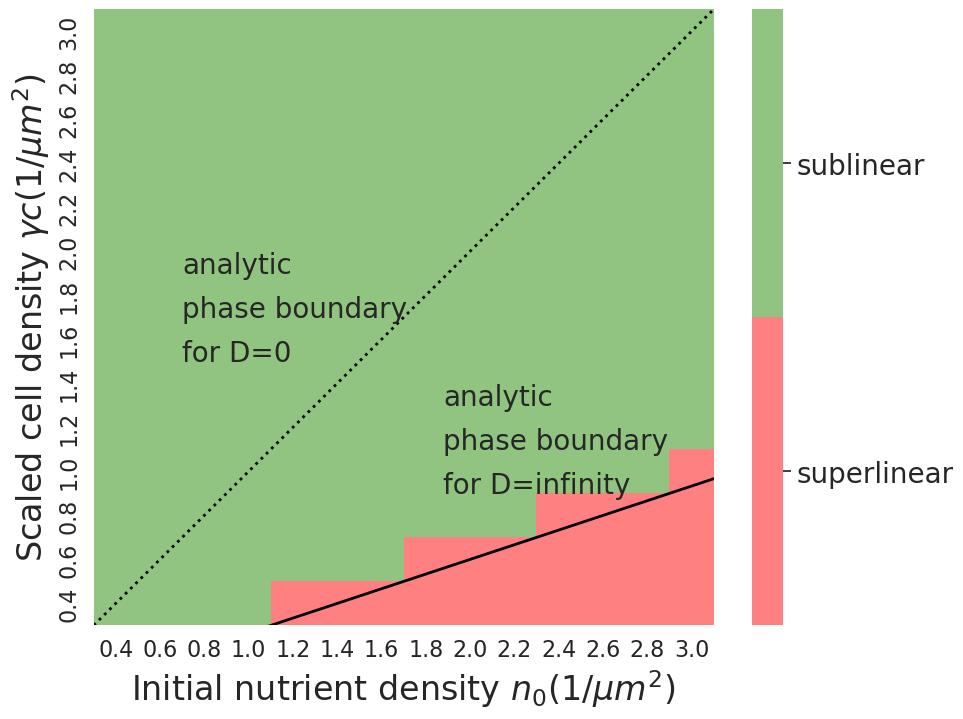

In [2]:
import numpy as np
import csv
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
with open('2d_sub_sl.csv', 'r') as f:
    reader = csv.reader(f)
    data = list(reader)
ndini=[0.4,0.6,0.8,1,1.2,1.4,1.6,1.8,2,2.2,2.4,2.6,2.8,3]
gama=[0.4,0.6,0.8,1,1.2,1.4,1.6,1.8,2,2.2,2.4,2.6,2.8,3]
sublinear = np.array(data, dtype="float")

print(sublinear)
df = pd.DataFrame(
    sublinear,
    columns=ndini,index=gama
)
#cmap = colors.ListedColormap(['red','black', 'blue'])
#colorbar.set_ticklabels(['exponential', 'linear', 'sublinear'])
myColors = ((0.1, 0.4, 1.0, 1.0), (1, 0.5, 0.1, 1.0))
myColors = ((1, 0, 0, 1.0), (0, 1, 0, 1.0))# (1.0, 1.0, 0.8, 1.0))

myColors = [(1.0, 0.5, 0.5,1.0), (0.57, 0.77, 0.5,1.0)]
cmap = LinearSegmentedColormap.from_list('Custom', myColors, len(myColors))
sns.set_theme(rc={'figure.figsize':(10,8)})
ax=sns.heatmap(df,cmap=cmap)#"YlGnBu")#, cbar_kws={'exponential': 0,'linear':0.5,'sublinear':1})
xa=np.linspace(0,20,20)
ax.plot(xa-2, xa-2, color='black', linestyle=":",linewidth=2)
ax.plot(xa-2, xa/3-2, color='black', linewidth=2)
ax.invert_yaxis()
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
c_bar = ax.collections[0].colorbar
c_bar.set_ticks([0.25, 0.75])
c_bar.set_ticklabels(['superlinear', 'sublinear'])
c_bar.ax.tick_params(labelsize=20)
plt.text(2.0,8,"analytic",fontsize=20)
plt.text(2.0,7,"phase boundary",fontsize=20)
plt.text(2.0,6,"for D=0",fontsize=20)

plt.text(7.9,5,"analytic",fontsize=20)
plt.text(7.9,4,"phase boundary",fontsize=20)
plt.text(7.9,3,"for D=infinity",fontsize=20)

#plt.title("2d expansion type with D and small L",fontsize=14)
plt.xlabel(r"Initial nutrient density $n_0(1/μm^2)$",fontsize=24)
plt.ylabel(r"Scaled cell density $\gamma c(1/μm^2)$",fontsize=24)
plt.savefig("2d_nutrient_phase_ofexpansion_type_small_l_unit_corrected.png",bbox_inches = 'tight',dpi=600)
plt.show()